# Отчет по анализу данных синтетического датасета E-commerce

## Импорт библиотек

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import dates as mdates
import seaborn as sns
from sqlalchemy import create_engine

In [3]:
USER = 'postgres'
PASSWORD = '********'
HOST = 'localhost'
PORT = '5432'
DB = 'e-commerce'

engine = create_engine(f'postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}')

In [4]:
query = '''select count(*)
from orders'''

df = pd.read_sql_query(query, engine)
df

,count
0,20000


## Знакомство и первичная оценка датасета

Датасет представляет собой набор таблиц, содержащий информацию о пользователях, товарах, заказах и данные для событийной аналитики

### Содержание таблиц

#### users - данные пользователей (количество записей 10k)

* user_id - уникальный ID пользователя
* name - полное имя пользователя
* email - электронная почта пользователя
* gender - пол пользователя
* city - город пользователя
* signup_date - дата создания аккаунта

#### products - данные о товарах (количество записей 2k)

* product_id - уникальный ID товара
* product_name - наименование товара
* category - категория товара
* price - актуальная цена
* rating - средняя оценка товара

#### orders - данные о заказах (количество записей 20k)

* order_id - уникальный ID заказа
* user_id - пользователь, оформивший заказ
* order_date - дата и время оформления заказа
* order_status - статус заказа
* total_amount - сумма заказа

#### order_items - данные о составе заказа (количество записей 43.5k)

* order_item_id - уникальный ID
* order_id - ID заказа
* product_id - ID товара
* quantity - количество позиций
* item_price - цена за 1 шт
* item_total - quantity * item_price

#### reviews - данные об отзывах (количество записей 15k)

* review_id - уникальный ID отзыва
* user_id - ID пользователя
* product_id - ID товара
* rating - оценка товара (от 1 до 5)
* review_text - краткое ревью отзыва
* review_date - дата отзыва

#### events - данные о событиях (количество записей 80k)

* event_id - уникальный ID события
* user_id - ID пользователя
* product_id - ID товара
* event_type - тип события (view/cart/wishlist/purchase)
* event_timestamp - дата и время события

#### Схема БД

![alt text](<postgres - E-commers - public.png>)

### Оценка качества данных

SQL запросы представлены в файле data_validation.sql

1. Размер таблиц:
    * пустых таблиц не обнаружено
    * количество записей не противоречит содержанию (например, количество записей в order_items не может быть меньше количества записей чем в orders)
2. Проверка уникальности ключевых полей
    * количество записей всех таблиц совпадает с количеством уникальных значений ключевых полей (таких как user_id)
3. Проверка наличия NULL-значений
    * отсутствие значений в критически важных полях не обнаружено
4. Проверка дубликатов
    * при проверке по ключевым полям дубликатов не обнаружено
5. Проверка диапазонов значений
    * значений, не соответствующих своему полю, не обнаружено
6. Проверка соответствия временных диапазонов
    * даты всех таблиц лежат в диапазоне 2024-01-01 - 2025-11-14
    * т.к. датасет синтетический, равенство диапазона дат регистрации пользователей диапазонам дат остальных таблиц не будет принято за аномалию
7. Проверка согласованности таблиц
    * в таблицах отсутствуют данные не имеющие связи с другими таблицами по ключевым полям
8. Оценка согласованности агрегатов
    * при сравнении рейтингов из таблиц reviews и products обнаружены расхождения рейтинга на 1990 товаров из представленных 1999 товаров в таблице reviews, что может указывать на предварительную агрегацию данных
    * расхождений цен в таблицах order_items и products не обнаружено, однако связывать данные поля нельзя, т.к. цена в products может измениться, в отличие от цены в order_items
    * расхождений сумм заказов в таблицах orders и order_items не обнаружено

## Разведочный анализ данных (EDA)

SQL запросы представлены в файле EDA.sql

### Продажи (Orders)

In [5]:
# SQL запрос
query = '''select
	date_trunc('month', o.order_date) as month,
	round(sum(o.total_amount) filter(where o.order_status not in ('cancelled', 'returned'))::numeric) as gmv,
	count(*) as total_orders,
	count(*) filter(where o.order_status not in ('cancelled', 'returned')) as successful_orders
from orders o
where date_trunc('month', o.order_date) != date '2025-11-01'
group by month
order by month'''

df_gmv_and_orders = pd.read_sql_query(query, engine)
df_gmv_and_orders['month_number'] = df_gmv_and_orders.month.dt.month
df_gmv_and_orders['month_name'] = df_gmv_and_orders.month.dt.strftime('%b')
df_gmv_and_orders['month_label'] = df_gmv_and_orders.month.dt.strftime('%Y-%m')
df_gmv_and_orders['year'] = df_gmv_and_orders.month.dt.to_period('Y')

df_gmv_and_orders.head(3)

,month,gmv,total_orders,successful_orders,month_number,month_name,month_label,year
0,2024-01-01,319814.0,881,522,1,Jan,2024-01,2024
1,2024-02-01,270452.0,814,482,2,Feb,2024-02,2024
2,2024-03-01,341429.0,950,593,3,Mar,2024-03,2024


#### GMV и количество заказов за период 2024-01-01 - 2025-10-31

Из анализа исключен ноябрь 2025 года, т.к. данные предоставлены не за полный месяц и могут искажать показатели и тренды

In [107]:
# GMV и количество заказов за весь период
df_gmv_and_orders.agg(
    {'gmv':'sum',
    'total_orders':'sum',
    'successful_orders':'sum'}
).round().to_frame().rename(columns={0:'sum'})

,sum
gmv,7020501.0
total_orders,19611.0
successful_orders,11774.0


Общее количество заказов - 19 611

#### GMV и количество заказов в разрезе месяца (общая динамика и сравнение по годам)

При расчете GMV исключены заказы со статусами `cancelled` и `returned`<br>
При сравнении показателей между годами исключены ноябрь и декабрь обоих годов для корректности сравнения

In [7]:
# GMV и количество заказов по годам
df_gmv_and_orders.query('month_number != 11 and month_number != 12').groupby('year').agg(
    total_gmv=('gmv','sum'),
    avg_gmv=('gmv','mean'),
    median_gmv=('gmv','median'),
    total_orders=('total_orders','sum'),
    avg_orders=('total_orders', 'mean'),
    median_orders=('total_orders', 'median'),
    months_present=('total_orders', 'count')
).round()

,total_gmv,avg_gmv,median_gmv,total_orders,avg_orders,median_orders,months_present
year,,,,,,,
2024,3257764.0,325776.0,329748.0,9006,901.0,898.0,10
2025,3123593.0,312359.0,311676.0,8842,884.0,889.0,10


In [8]:
# разница в процентах

df_gmv_and_orders.query('month_number != 11 and month_number != 12').groupby('year').agg(
    total_gmv=('gmv','sum'),
    avg_gmv=('gmv','mean'),
    median_gmv=('gmv','median'),
    total_orders=('total_orders','sum'),
    avg_orders=('total_orders', 'mean'),
    median_orders=('total_orders', 'median')
).pct_change().mul(100).round(2).dropna()

,total_gmv,avg_gmv,median_gmv,total_orders,avg_orders,median_orders
year,,,,,,
2025,-4.12,-4.12,-5.48,-1.82,-1.82,-1.06


* В 2025 году показатели GMV и количества заказов в среднем несколько ниже по сравнению с 2024 годом, однако различия показателей между периодами остаются незначительными

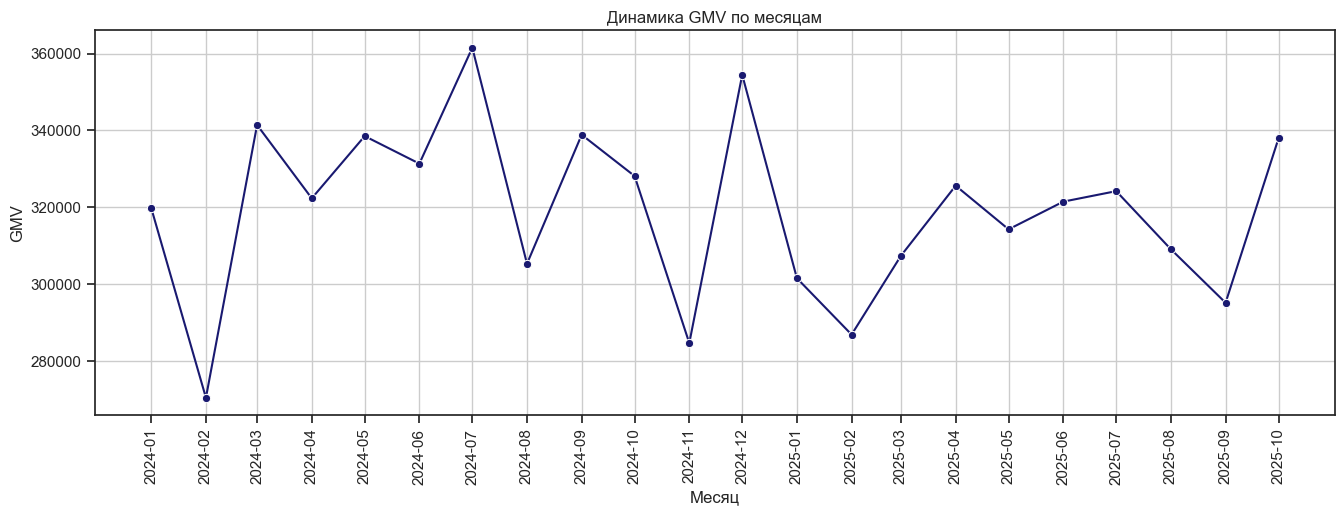

In [9]:
sns.set_theme(style='ticks')
plt.figure(figsize=(16, 5))
ax = sns.lineplot(
    data=df_gmv_and_orders, 
    x='month', 
    y='gmv', 
    marker='o',
    color='midnightblue'
)

plt.title('Динамика GMV по месяцам')
plt.xlabel('Месяц')
plt.ylabel('GMV')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(df_gmv_and_orders.month, rotation=90)

plt.grid()

plt.show()

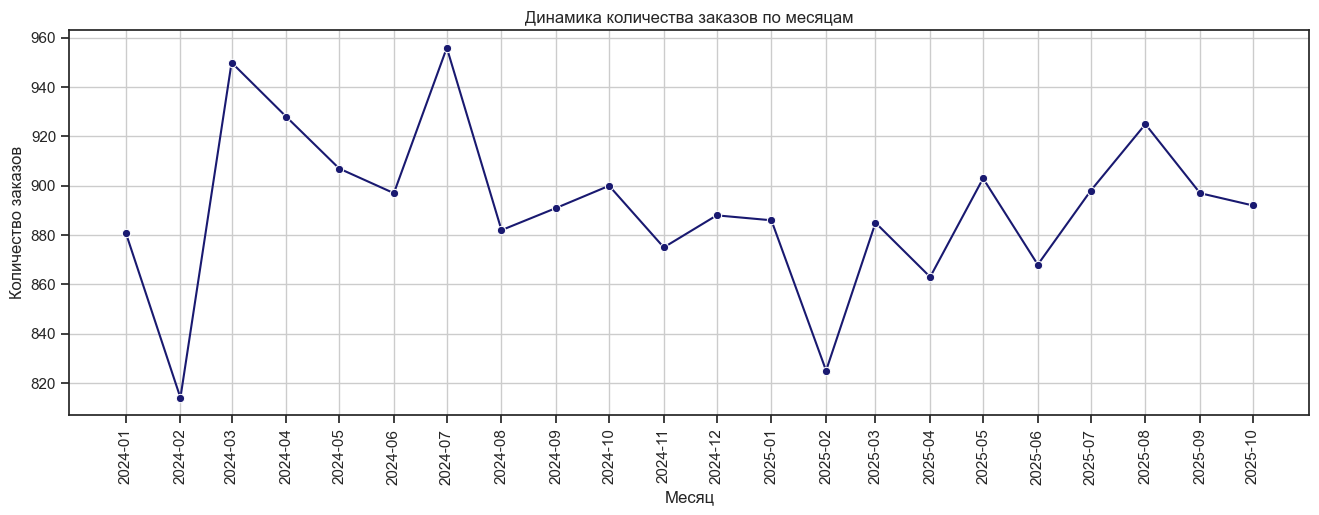

In [10]:
plt.figure(figsize=(16, 5))
ax = sns.lineplot(
    data=df_gmv_and_orders, 
    x='month', 
    y='total_orders', 
    marker='o',
    color='midnightblue'
)

plt.title('Динамика количества заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(df_gmv_and_orders.month, rotation=90)

plt.grid()

plt.show()

In [119]:
df_gmv_and_orders[['gmv','total_orders']].mean().round().to_frame().rename(columns={0:'average per month'})

,average per month
gmv,319114.0
total_orders,891.0


* наблюдается спад GMV и количества заказов в феврале и в 2024, и в 2025 годах. Возможной причиной может быть сезонный спад потребительской активности после новогоднего периода
* динамика GMV в целом повторяет динамику количества заказов
* в 2025 году наблюдается меньше выраженных пиков GMV и количества заказов по сравнению с 2024 годом

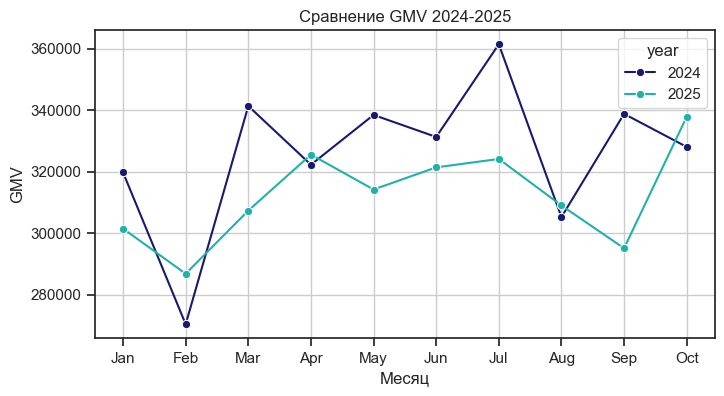

In [11]:
plt.figure(figsize=(8, 4))
ax = sns.lineplot(
    data=df_gmv_and_orders.query('month_number != 11 and month_number != 12'), 
    x='month_name', 
    y='gmv', 
    hue='year',
    marker='o',
    palette=['midnightblue','lightseagreen']
)

plt.title('Сравнение GMV 2024-2025')
plt.xlabel('Месяц')
plt.ylabel('GMV')

plt.grid()

plt.show()

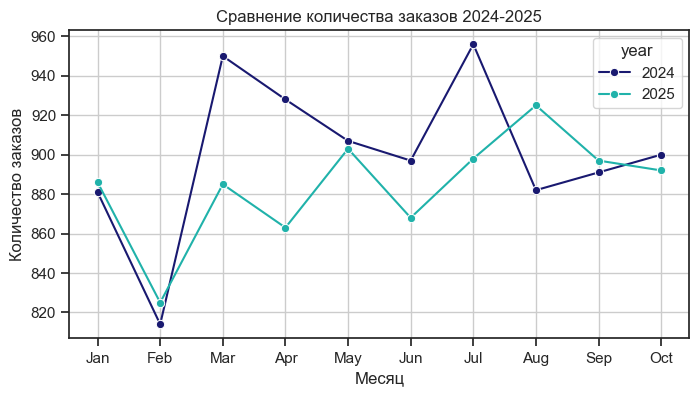

In [12]:
plt.figure(figsize=(8, 4))
sns.lineplot(
    data=df_gmv_and_orders.query('month_number != 11 and month_number != 12'), 
    x='month_name', 
    y='total_orders', 
    hue='year',
    marker='o',
    palette=['midnightblue','lightseagreen']
)

plt.title('Сравнение количества заказов 2024-2025')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')

plt.grid()

plt.show()

* тренды GMV и количества заказов в 2025 году выглядят более равномерными по сравнению с динамикой 2024 года

#### Распределение стоимости заказов

In [13]:
# SQL запрос
query = '''select
	date_trunc('month', o.order_date) as month,
	o.order_id,
	o.total_amount 
from orders o 
where date_trunc('month', o.order_date ) != date '2025-11-01'
'''

df_orders_value = pd.read_sql_query(query, engine)
df_orders_value['value_bin'] = pd.cut(df_orders_value['total_amount'], bins=[0, 500, 2000, 4000, 8000], labels=['0-500', '500-2000', '2000-4000', '4000-8000'])
df_orders_value['month_number'] = df_orders_value.month.dt.month
df_orders_value['year'] = df_orders_value.month.dt.to_period('Y')
df_orders_value.head(3)

,month,order_id,total_amount,value_bin,month_number,year
0,2025-09-01,O00000001,689.66,500-2000,9,2025
1,2025-04-01,O00000002,1666.85,500-2000,4,2025
2,2025-04-01,O00000003,665.06,500-2000,4,2025


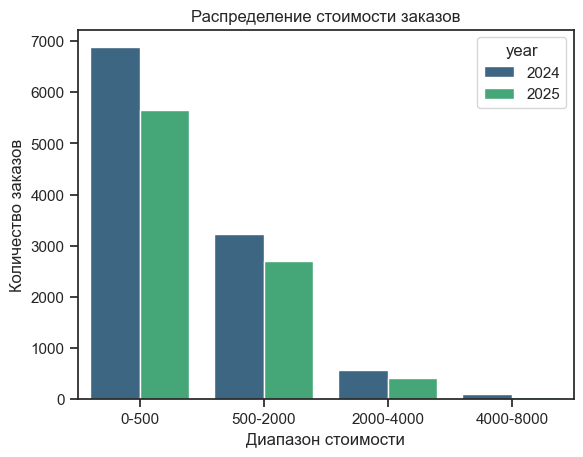

In [14]:
sns.barplot(
    data=df_orders_value.groupby(['year','value_bin']).order_id.count().reset_index(),
    x='value_bin',
    y='order_id',
    hue='year',
    palette='viridis'
)

plt.title('Распределение стоимости заказов')
plt.xlabel('Диапазон стоимости')
plt.ylabel('Количество заказов')

plt.show()

In [15]:
df_orders_value.total_amount.quantile(0.75)

np.float64(763.65)

* наибольшая часть заказов в 2024 и 2025 году находится в диапазоне стоимости от 0 до 500
* третий квартиль стоимости заказов - 763,65

#### Распределение статусов заказов

In [16]:
# SQL запрос
query = '''select
	order_status,
	count(*) as orders_count,
	round(count(*)::numeric/(select count(*) from orders)::numeric*100, 2) as pct_of_total
from orders o 
group by o.order_status
order by orders_count desc'''

df_orders_status = pd.read_sql_query(query, engine)
df_orders_status.head()

,order_status,orders_count,pct_of_total
0,shipped,4113,20.57
1,returned,4066,20.33
2,completed,4021,20.11
3,cancelled,3920,19.60
4,processing,3880,19.40


In [17]:
# проверка корректности запроса (сумма процентов должна быть равна 100)
df_orders_status.pct_of_total.sum().round()

np.float64(100.0)

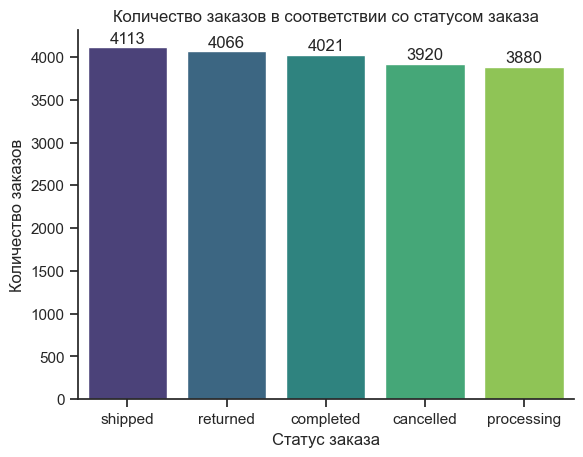

In [18]:
ax = sns.barplot(
    data=df_orders_status,
    x='order_status',
    y='orders_count',
    hue='order_status',
    palette='viridis'
)

for i in ax.containers:
    plt.bar_label(i, padding=1)
    
ax.spines[['top', 'right']].set_visible(False)

plt.title('Количество заказов в соответствии со статусом заказа')
plt.xlabel('Статус заказа')
plt.ylabel('Количество заказов')

plt.show()

* 19,6 % заказов оформленных за исследуемый период отменены
* оформлено 20,33 % возвратов за исследуемый период
* процент завершенных заказов составил 20,11 %
* почти 2/5 из всех оформленных заказов не были успешно завершены
* предположительно, сопостовимые соотношения статусов заказов связаны с синтетической природой исследуемого датасета

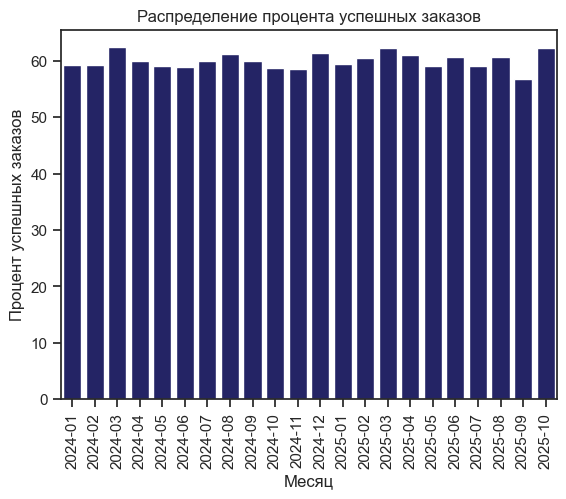

In [19]:
ax = sns.barplot(
    df_gmv_and_orders, 
    x='month_label', 
    y=(df_gmv_and_orders['successful_orders']*100/df_gmv_and_orders['total_orders']),
    color='midnightblue'
)

plt.title('Распределение процента успешных заказов')
plt.xlabel('Месяц')
plt.ylabel('Процент успешных заказов')

plt.xticks(rotation=90)

plt.show()

In [20]:
# SQL запрос

query = '''select
	date_trunc('month',o.order_date) as month,
	order_status,
	count(*) as orders_count
from orders o 
where o.order_status in ('cancelled', 'returned') and date_trunc('month',o.order_date) != date '2025-11-01'
group by date_trunc('month',o.order_date), o.order_status
order by date_trunc('month',o.order_date)'''

df_orders_status_per_month = pd.read_sql_query(query, engine)
df_orders_status_per_month.head()

,month,order_status,orders_count
0,2024-01-01,cancelled,172
1,2024-01-01,returned,187
2,2024-02-01,cancelled,163
3,2024-02-01,returned,169
4,2024-03-01,cancelled,176


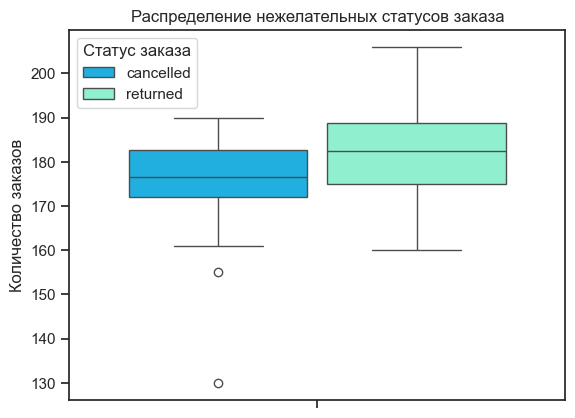

In [21]:
sns.boxplot(
    data=df_orders_status_per_month,
    y='orders_count',
    hue='order_status',
    palette=['deepskyblue','aquamarine'],
    gap=0.1
)

plt.title('Распределение нежелательных статусов заказа')
plt.ylabel('Количество заказов')
plt.legend(title='Статус заказа')

plt.show()

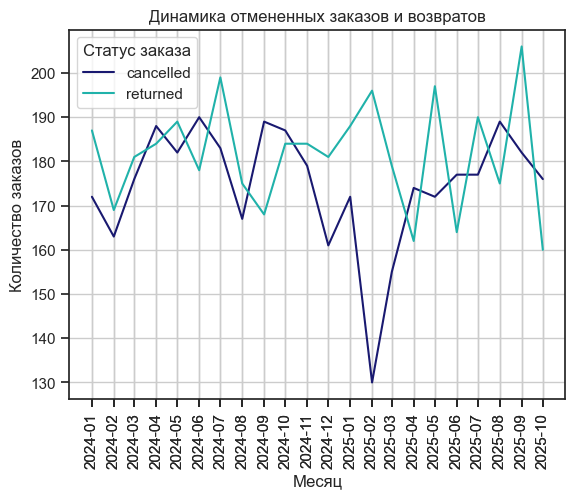

In [22]:
ax = sns.lineplot(
    data=df_orders_status_per_month, 
    x='month',
    y='orders_count',
    hue='order_status',
    palette=['midnightblue','lightseagreen']
)

plt.title('Динамика отмененных заказов и возвратов')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.legend(title='Статус заказа')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(ticks=df_orders_status_per_month.month, rotation=90)

plt.grid()

plt.show()

* резкого увеличения количества отмененных заказов и возвратов за исследуемый период не обнаружено
* в среднем, количество возвращенных заказов превышает количество отмененных заказов

#### AOV (средний чек)

In [23]:
# SQL запрос
query = '''select 
	round(avg(o.total_amount )::numeric, 2) as total_aov,
	round(avg(o.total_amount ) filter(where o.order_status not in ('cancelled', 'returned'))::numeric, 2) as clean_aov
from orders o ;'''

df_aov = pd.read_sql_query(query, engine)
df_aov

,total_aov,clean_aov
0,595.93,598.72


`total_aov` - средний чек по всем заказам <br>
`clean_aov` - средний чек по заказам за исключением заказов со статусами cancelled/returned

* средний чек заказов со статусами cancelled/returned сопоставим со средним чеком всех заказов

#### AOV в разрезе месяца

Ноябрь 2025 не учитывается при анализе в связи с неполнотой данных

In [24]:
query = '''select 
	date_trunc('month', o.order_date) as month,
	round(avg(o.total_amount )::numeric, 2) as total_aov
from orders o 
where date_trunc('month', o.order_date) != '2025-11-01'
group by date_trunc('month', o.order_date)
order by date_trunc('month', o.order_date)'''

df_aov_per_month = pd.read_sql_query(query, engine)
df_aov_per_month['month_number'] = df_aov_per_month.month.dt.month
df_aov_per_month['month_name'] = df_aov_per_month.month.dt.strftime('%b')
df_aov_per_month['year'] = df_aov_per_month.month.dt.to_period('Y')
df_aov_per_month.head()

,month,total_aov,month_number,month_name,year
0,2024-01-01,616.48,1,Jan,2024
1,2024-02-01,631.10,2,Feb,2024
2,2024-03-01,569.70,3,Mar,2024
3,2024-04-01,587.96,4,Apr,2024
4,2024-05-01,609.37,5,May,2024


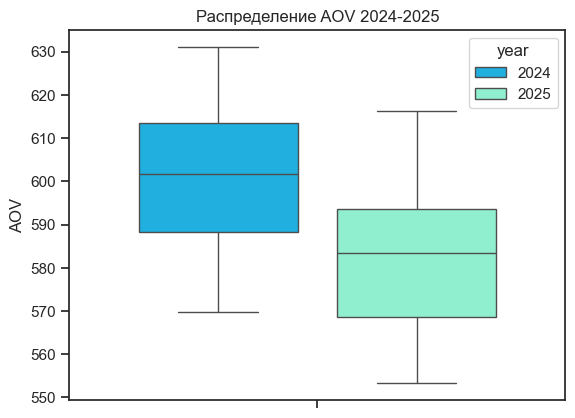

In [25]:
sns.boxplot(
    data=df_aov_per_month.query('month_number != 11 & month_number != 12'),
    y='total_aov',
    hue='year',
    palette=['deepskyblue','aquamarine'],
    gap=0.2
)

plt.title('Распределение AOV 2024-2025')
plt.ylabel('AOV')

plt.show()

* AOV в 2025 году незначительно снижен, по сравнению с 2024 годом

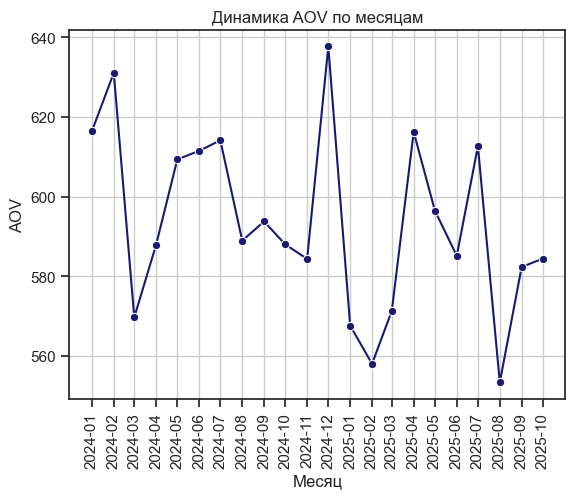

In [26]:
ax = sns.lineplot(
    data=df_aov_per_month,
    x='month',
    y='total_aov',
    marker='o',
    color='midnightblue'
)

plt.title('Динамика AOV по месяцам')
plt.xlabel('Месяц')
plt.ylabel('AOV')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(df_aov_per_month.month, rotation=90)

plt.grid()

plt.show()

* наименьшие значения AOV за исследуемый период наблюдаются в марте 2024, феврале и августе 2025

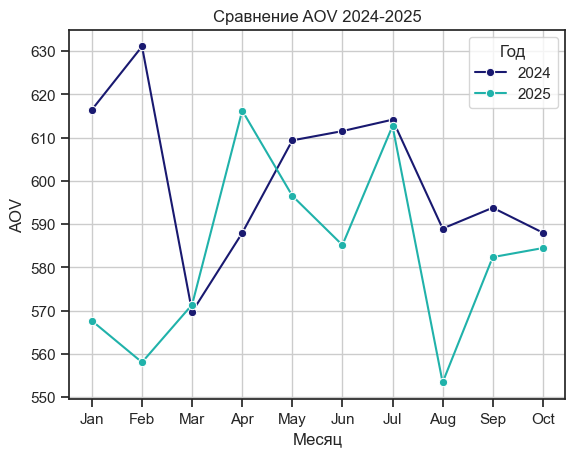

In [27]:
sns.lineplot(
    data=df_aov_per_month.query('month_number != 11 & month_number != 12'),
    x='month_name',
    y='total_aov',
    hue='year',
    marker='o',
    palette=['midnightblue','lightseagreen']
)

plt.title('Сравнение AOV 2024-2025')
plt.xlabel('Месяц')
plt.ylabel('AOV')
plt.legend(title='Год')

plt.grid()

plt.show()

* несмотря на сниженное количество заказов в феврале 2024, в данный месяц наблюдается наиболее высокий AOV за исследуемый период. При этом в феврале 2025 года высокий показатель AOV не наблюдается
* динамики показателя AOV в 2024 и 2025 году имеют разные периоды роста и спада

### Товары (Products)

#### Количество продаж и выручка в разрезе категорий

In [28]:
# SQL запрос
query = '''select 
	p.category , 
	sum(oi.quantity ) as sold_items, 
	round(sum(oi.item_total )) as gmv,
	round(avg(oi.item_price)::numeric, 2) as avg_price
from order_items oi 
inner join orders o 
	on oi.order_id = o.order_id 
inner join products p 
	on oi.product_id = p.product_id
group by p.category 
order by gmv'''

df_category = pd.read_sql_query(query, engine)
df_category.head()

,category,sold_items,gmv,avg_price
0,Groceries,5417,89398.0,16.36
1,Books,6068,274826.0,45.12
2,Pet Supplies,6717,354035.0,52.60
3,Toys,6519,385484.0,58.95
4,Beauty,6329,555775.0,88.04


In [29]:
df_category['gmv_share'] = (df_category.gmv*100/df_category.gmv.sum()).round(1)

In [30]:
gmv_share = [f'{i} %' for i in df_category['gmv_share']]

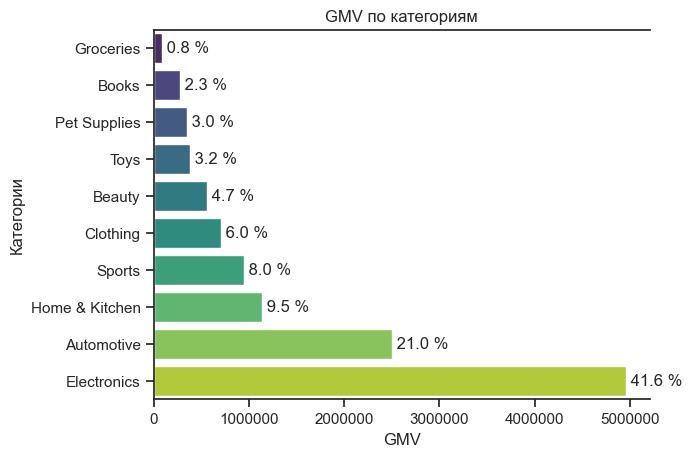

In [31]:
ax = sns.barplot(
    data=df_category, 
    x='gmv', 
    y='category', 
    hue='category', 
    palette='viridis'
)

for i, row in enumerate(df_category.itertuples()):
    ax.text(
        x=row.gmv,
        y=i,
        s=f' {row.gmv_share} %',
        va='center'
    )

plt.title('GMV по категориям')
plt.xlabel('GMV')
plt.ylabel('Категории')

ax.spines.right.set_visible(False)

plt.ticklabel_format(axis='x', style='plain')

plt.show()

На категории Electronics и Automotive приходится 62,6 % от общего GMV.

Данные на следующих двух графиках отсортированы по возрастанию GMV

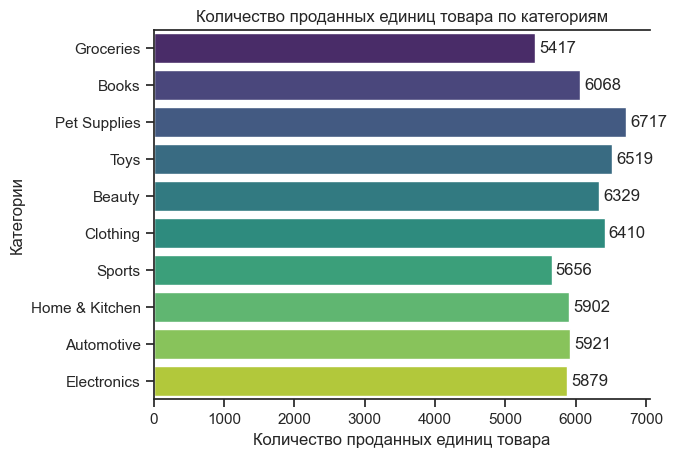

In [32]:
ax = sns.barplot(
    data=df_category.sort_values('gmv'), 
    x='sold_items', 
    y='category', 
    hue='category', 
    palette='viridis'
)
for i in ax.containers:
    plt.bar_label(i, padding=3)

plt.title('Количество проданных единиц товара по категориям')
plt.xlabel('Количество проданных единиц товара')
plt.ylabel('Категории')

ax.spines.right.set_visible(False)

plt.ticklabel_format(axis='x', style='plain')

plt.show()

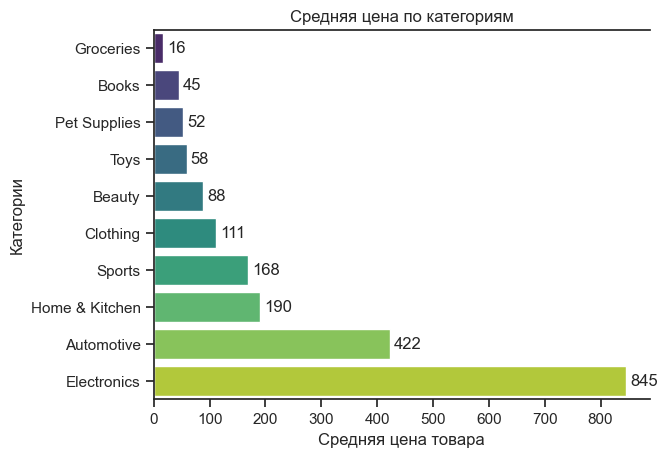

In [33]:
ax = sns.barplot(
    data=df_category.sort_values('gmv'), 
    x='avg_price', 
    y='category', 
    hue='category', 
    palette='viridis'
)

for i in ax.containers:
    plt.bar_label(i, fmt='%i',padding=3)

plt.title('Средняя цена по категориям')
plt.xlabel('Средняя цена товара')
plt.ylabel('Категории')

ax.spines.right.set_visible(False)

plt.ticklabel_format(axis='x', style='plain')

plt.show()

* категории Electronics и Automotive имеют значительно более высокий GMV, по сравнению с другими категориями
* меньше всего GMV приносит категория Groceries
* несмотря на широкую разницу средних цен между категориями, количество проданных единиц товаров сопоставимы (возможно связано с синтетической природой датафрейма)

In [34]:
# SQL-запрос

query = '''select
date_trunc('month', order_date) as month,
p.category ,
sum(oi.item_total ) as gmv
from products p
inner join order_items oi 
	on p.product_id = oi.product_id
inner join orders o 
	on oi.order_id = o.order_id
where date_trunc('month', order_date) != date '2025-11-01'
group by month , p.category '''

df_category_per_month = pd.read_sql_query(query, engine)
df_category_per_month.head()

,month,category,gmv
0,2024-07-01,Home & Kitchen,48277.332
1,2024-08-01,Home & Kitchen,48378.098
2,2024-05-01,Groceries,4601.472
3,2025-08-01,Toys,18368.360
4,2024-11-01,Electronics,210967.840


In [35]:
# pivot
df_category_per_month_p = df_category_per_month.pivot_table(
    columns='month', 
    index='category', 
    values='gmv'
)
df_category_per_month_p.columns = df_category_per_month_p.columns.strftime('%Y-%m')

In [36]:
# сортировка категорий по общему gmv
category_order = (
    df_category_per_month
    .groupby('category')
    .gmv
    .sum()
    .sort_values(ascending=False)
    .index
)
df_category_per_month_p = df_category_per_month_p.loc[category_order]

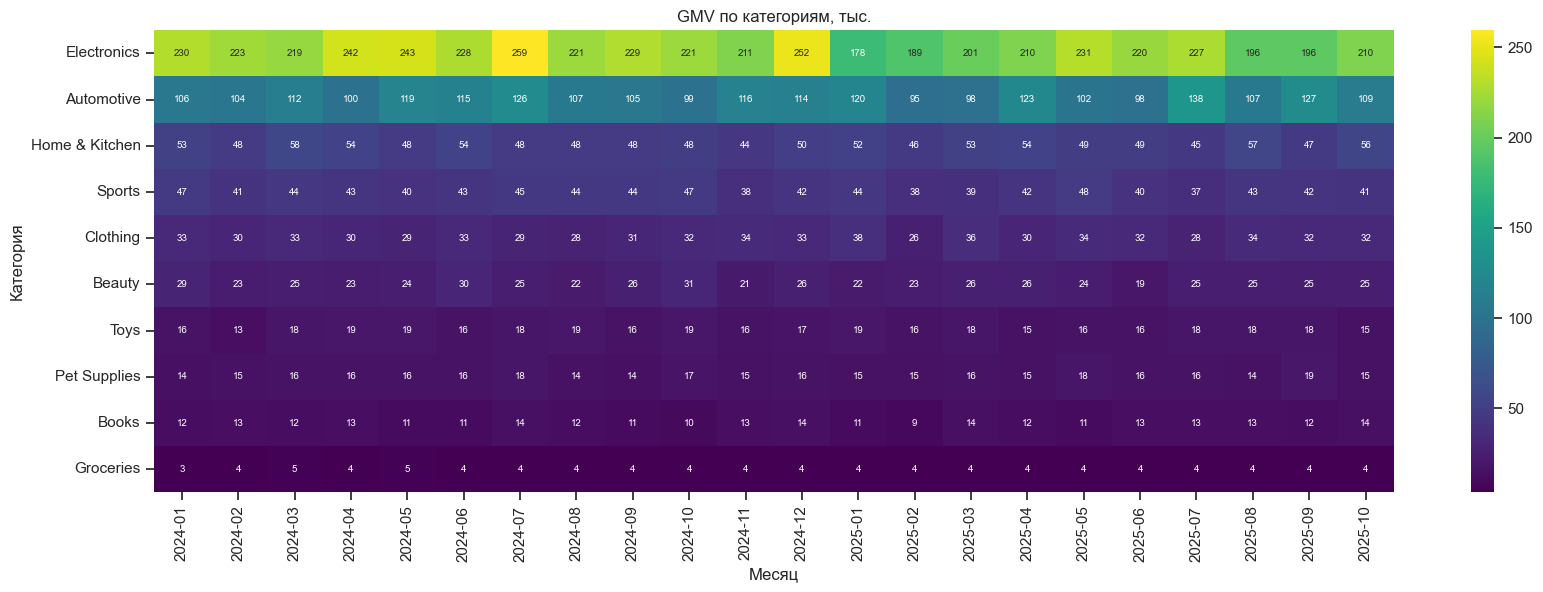

In [37]:
plt.figure(figsize=(20,6))

ax = sns.heatmap(
    df_category_per_month_p.div(1000),
    annot=True,
    annot_kws=({'size':7}),
    fmt='.0f',
    cmap='viridis',
)
plt.title('GMV по категориям, тыс.')
plt.xlabel('Месяц')
plt.ylabel('Категория')

plt.xticks(rotation=90)

plt.show()

In [38]:
# изменения gmv в процентах
df_category_per_month_pct = (df_category_per_month_p
                           .T
                           .pct_change()
                           .unstack()
                           .reset_index()
                           .dropna()
                           .rename(columns={0:'pct_change'}))

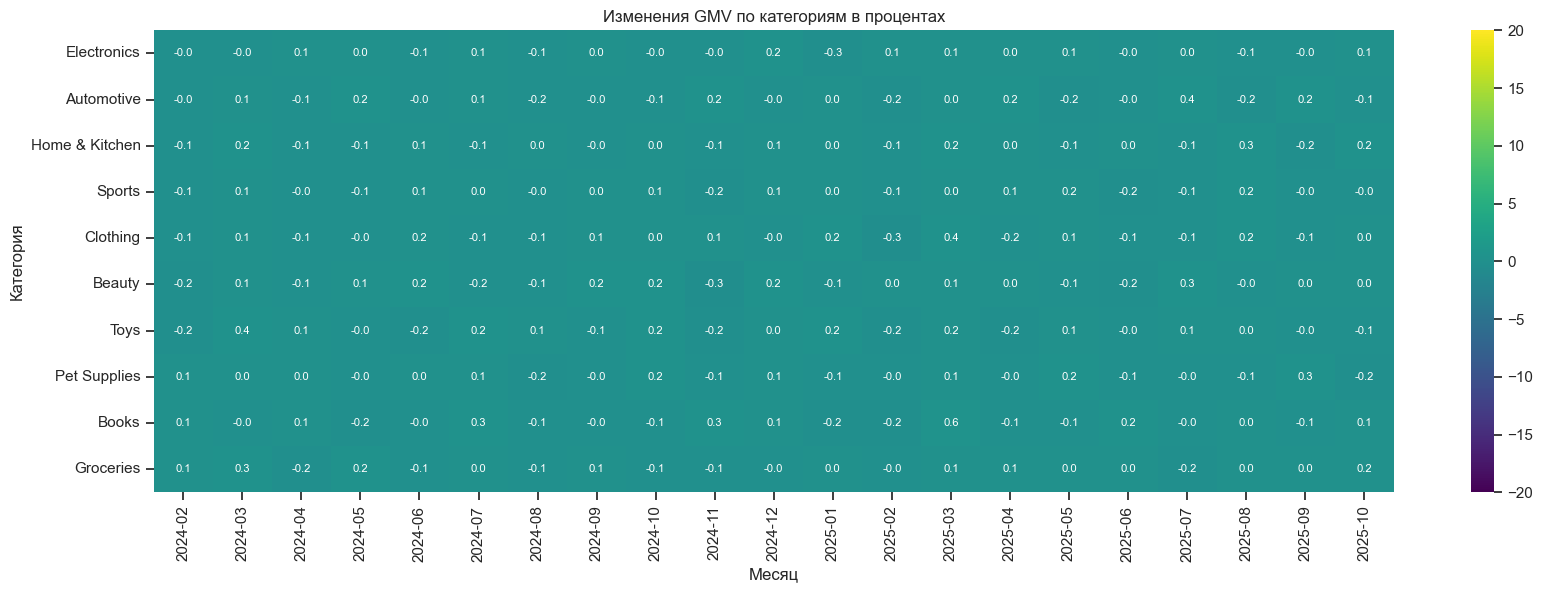

In [39]:
plt.figure(figsize=(20,6))

sns.heatmap(
    data=(df_category_per_month_p
          .T
          .pct_change()
          .dropna()
          .T),
    annot=True,
    annot_kws=({'size':8}),
    vmin=-20,
    vmax=20,
    fmt='.1f',
    cmap='viridis'
)

plt.title('Изменения GMV по категориям в процентах')
plt.xlabel('Месяц')
plt.ylabel('Категория')

plt.xticks(rotation=90)

plt.show()

Категории на heatmap отсортированы по уменьшению их GMV

* в среднем не наблюдается значительных изменений GMV за исследуемый период
* сезонных или каких-либо ещё колебаний GMV не наблюдается, что предположительно связано с синтетической природой датасета

#### Отмены и возвраты по категориям

Категории на графиках отсортированы по убыванию их GMV

In [40]:
# SQL-запрос

query = '''select 
	p.category,
	count(distinct o.order_id) 
		filter(where o.order_status = 'cancelled') as count_cancellations,
	round(count(distinct o.order_id) 
		filter(where o.order_status = 'cancelled')::numeric / count(distinct o.order_id)*100, 1) as cancellation_rate,
	round(sum(o.total_amount) 
		filter(where o.order_status = 'cancelled')::numeric) as revenue_lost
from orders o 
inner join order_items oi 
	on o.order_id = oi.order_id
inner join products p 
	on oi.product_id = p.product_id
group by p.category'''

df_cancel = pd.read_sql_query(query, engine)
df_cancel.head()

,category,count_cancellations,cancellation_rate,revenue_lost
0,Automotive,744,19.2,850150.0
1,Beauty,799,19.3,546416.0
2,Books,782,20.0,517843.0
3,Clothing,828,19.9,612102.0
4,Electronics,754,19.5,1409540.0


In [41]:
# сортировка категорий по общему gmv
df_cancel = df_cancel.set_index('category').loc[category_order]

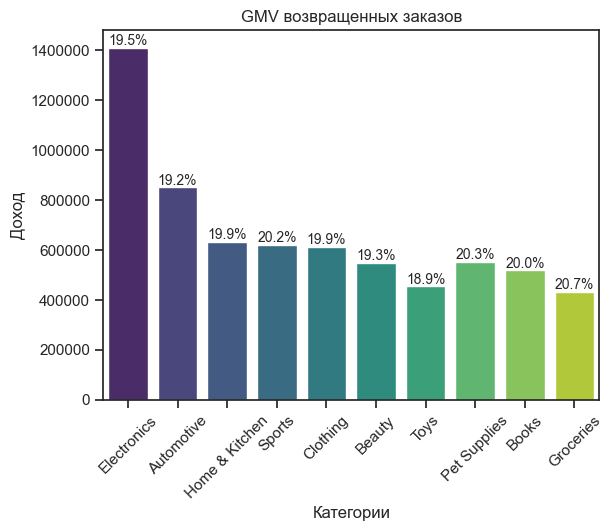

In [42]:
ax = sns.barplot(
    data=df_cancel,
    x='category',
    y='revenue_lost',
    hue='category',
    palette='viridis'
)

for i, row in enumerate(df_cancel.itertuples()):
    ax.text(
        x=i,
        y=row.revenue_lost,
        s=f'{row.cancellation_rate}%',
        ha='center',
        va='bottom',
        size='small'
    )

plt.title('GMV возвращенных заказов')
plt.xlabel('Категории')
plt.ylabel('Доход')

plt.xticks(rotation=45)
plt.ticklabel_format(axis='y', style='plain')

plt.show()

In [43]:
#SQL-запрос

query = '''select 
	p.category,
	count(distinct o.order_id) 
		filter(where o.order_status = 'returned') as count_returns,
	round(count(distinct o.order_id) 
		filter(where o.order_status = 'returned')::numeric / count(distinct o.order_id)*100, 1) as returns_rate,
	round(sum(o.total_amount) 
		filter(where o.order_status = 'returned')::numeric) as revenue_lost
from orders o 
inner join order_items oi 
	on o.order_id = oi.order_id
inner join products p 
	on oi.product_id = p.product_id
group by p.category;'''

df_return = pd.read_sql_query(query, engine)
df_return.head()

,category,count_returns,returns_rate,revenue_lost
0,Automotive,762,19.6,927628.0
1,Beauty,827,20.0,580547.0
2,Books,798,20.4,511679.0
3,Clothing,807,19.4,566935.0
4,Electronics,809,21.0,1518480.0


In [44]:
# сортировка категорий
df_return = df_return.set_index('category').loc[category_order]

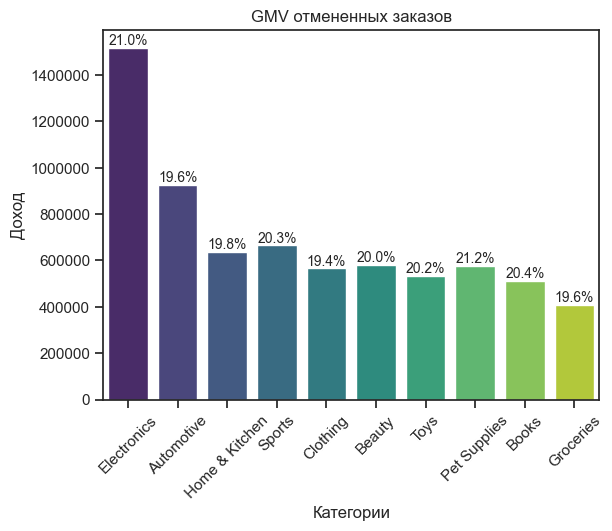

In [45]:
ax = sns.barplot(
    data=df_return,
    x='category',
    y='revenue_lost',
    hue='category',
    palette='viridis'
)

for i, row in enumerate(df_return.itertuples()):
    ax.text(
        x=i,
        y=row.revenue_lost,
        s=f'{row.returns_rate}%',
        ha='center',
        va='bottom',
        size='small'
    )
plt.title('GMV отмененных заказов')
plt.xlabel('Категории')
plt.ylabel('Доход')

plt.xticks(rotation=45)
plt.ticklabel_format(axis='y', style='plain')

plt.show()

* cancellation rate и return rate сопостовимы как между категориями, так и между собой. Вероятнее всего такая аномальная схожесть показателей обусловнена синтетической природой датасета
* наибольшие потери дохода приходятся на категории Electronics и Automotive, вледствие более высокой стоимости товара
* не наблюдаются явные пики или спады cancellation rate и returns rate

### Анализ когорт

#### Условия анализа

* из анализа когорт исключены заказы со статусами 'cancelled' и 'returned'
* когорты пользователей сформированы на основании месяца их первого заказа
* для heatmap были выбраны когорты, по которым имеются данные минимум за 12 месяцев
* 0 месяц соответствует месяцу формирования когорты
* указанные показатели для исследуемых когорт рассмотрены на протяжении 12 месяцев (для retention rate был исключен первый месяц, т.к. данный показатель для первого месяца всегда равен 100 %)

In [46]:
# SQL запрос
query = '''with c as (
select 
	date(date_trunc('month', min(o.order_date) )) as cohort_month,
	o.user_id 
from orders o
where o.order_status not in ('cancelled', 'returned')
group by o.user_id 
)

select 
	c.cohort_month,
	date(date_trunc('month', o.order_date)) as purchase_month,
	extract(month from age(date(date_trunc('month', o.order_date)),cohort_month))
	+
	extract(year from age(date(date_trunc('month', o.order_date)),cohort_month))*12 as purchase_month_number,
	count(distinct o.user_id ) count_users,
	round(sum(o.total_amount )) as gmv,
	round(sum(o.total_amount )::numeric/count(distinct o.user_id ), 2) arppu
from c
inner join orders o 
	on c.user_id = o.user_id 
where o.order_status not in ('cancelled', 'returned')
group by cohort_month, date(date_trunc('month', o.order_date))
order by cohort_month, date(date_trunc('month', o.order_date));
'''

df_cohort = pd.read_sql_query(query, engine)
df_cohort['cohort_month'] = df_cohort.cohort_month.astype('datetime64[ns]')

df_cohort.head()

,cohort_month,purchase_month,purchase_month_number,count_users,gmv,arppu
0,2024-01-01,2024-01-01,0.0,512,319814.0,624.64
1,2024-01-01,2024-02-01,1.0,28,16834.0,601.20
2,2024-01-01,2024-03-01,2.0,28,20518.0,732.78
3,2024-01-01,2024-04-01,3.0,21,15984.0,761.14
4,2024-01-01,2024-05-01,4.0,15,17172.0,1144.79


#### Retention rate

In [47]:
# pivot по кол-ву пользователей
df_cohort_users_p = pd.pivot_table(
    data=df_cohort, 
    index='cohort_month', 
    columns='purchase_month_number', 
    values='count_users'
)
df_cohort_users_p.index = df_cohort_users_p.index.strftime('%Y-%m')

In [48]:
# retention rate
df_cohort_users_p_rr = df_cohort_users_p.div(df_cohort_users_p[0], axis=0).mul(100)

In [49]:
# df для heatmap
df_cohort_users_heatmap = df_cohort_users_p_rr.iloc[::, 1:13].dropna()

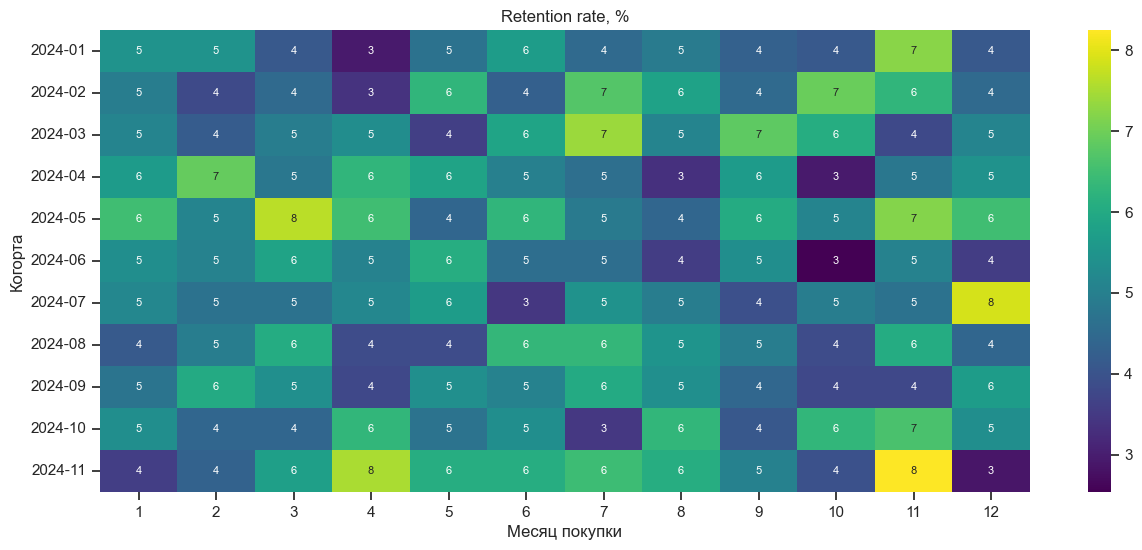

In [50]:
plt.figure(figsize=(15,6))
ax = sns.heatmap(
    df_cohort_users_heatmap,
    annot=True,
    fmt='.0f',
    cmap='viridis',
    annot_kws={'size':8}
)
plt.title('Retention rate, %')
plt.xlabel('Месяц покупки')
plt.ylabel('Когорта')
ax.set_xticks([i + 0.5 for i in range(len(df_cohort_users_heatmap.columns))])
ax.set_xticklabels(df_cohort_users_heatmap.columns.astype(int))
plt.show()

* показатель retention rate после первого месяца исследуемых когорт снижается до 3-8 % и остается относительно стабильным в течение дальнейшего периода наблюдения, что может быть связано с синтетической природой исследуемого датасета

#### GMV

In [51]:
# pivot по gmv
df_cohort_gmv_p = pd.pivot_table(
    data=df_cohort,
    index='cohort_month',
    columns='purchase_month_number',
    values='gmv'
)
df_cohort_gmv_p.index = df_cohort_gmv_p.index.strftime('%Y-%m')

In [52]:
# df для heatmap
df_cohort_gmv_heatmap = df_cohort_gmv_p.iloc[::, :12].dropna()

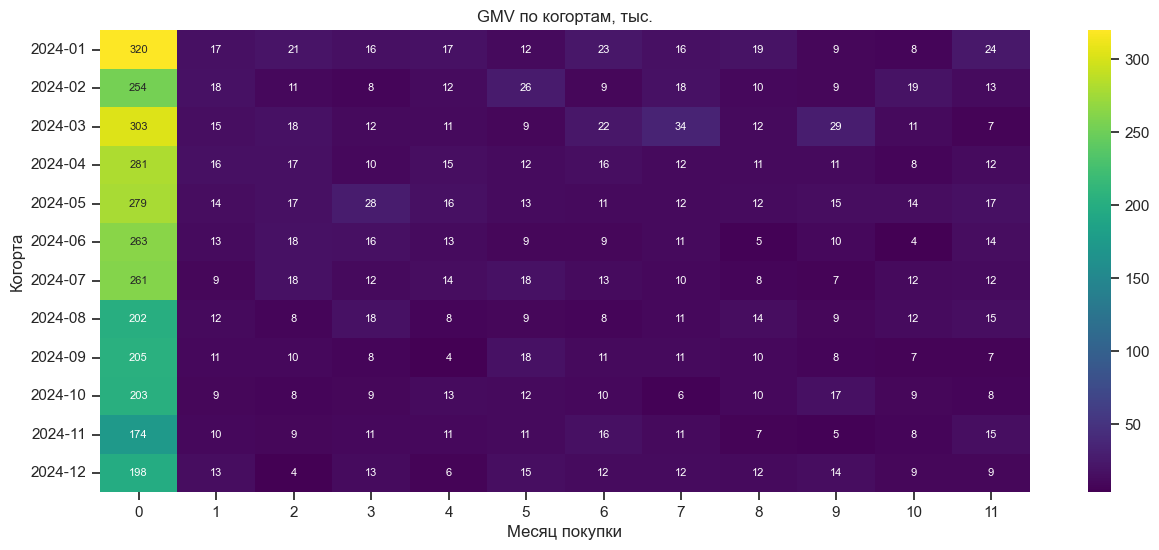

In [53]:
plt.figure(figsize=(15,6))

ax = sns.heatmap(
    df_cohort_gmv_heatmap.div(1000),
    annot=True,
    fmt='.0f',
    cmap='viridis',
    annot_kws={'size':8}
)

plt.title('GMV по когортам, тыс.')
plt.xlabel('Месяц покупки')
plt.ylabel('Когорта')

ax.set_xticks([i + 0.5 for i in range(len(df_cohort_gmv_heatmap.columns))])
ax.set_xticklabels(df_cohort_gmv_heatmap.columns.astype(int))

plt.show()

* наблюдается снижение GMV первого месяца в новых когортах
* для более удобной оценки дальнейшей динамики GMV когорт, в следующем графике исключен месяц создания когорты

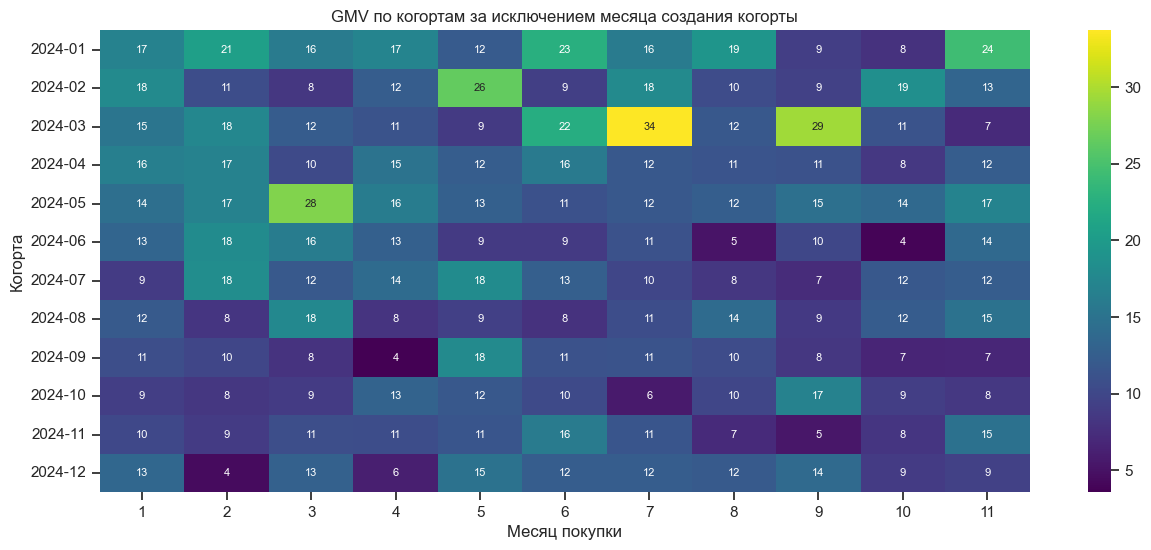

In [54]:
plt.figure(figsize=(15,6))

ax = sns.heatmap(
    df_cohort_gmv_heatmap.iloc[::, 1:].div(1000),
    annot=True,
    fmt='.0f',
    cmap='viridis',
    annot_kws={'size':8}
)

plt.title('GMV по когортам за исключением месяца создания когорты')
plt.xlabel('Месяц покупки')
plt.ylabel('Когорта')

ax.set_xticks([i + 0.5 for i in range(len(df_cohort_gmv_heatmap.iloc[::, 1:].columns))])
ax.set_xticklabels(df_cohort_gmv_heatmap.iloc[::, 1:].columns.astype(int))

plt.show()

* визуально "старые" когорты исследуемого периода имеют более высокий усредненный GMV, чем "новые" когорты
* не наблюдается периодов, в котором бы значительно изменился GMV по всем рассмотренным когортам одновременно

#### ARPPU

In [55]:
# pivot по arppu
df_cohort_arppu_p = pd.pivot_table(
    data=df_cohort,
    index='cohort_month',
    columns='purchase_month_number',
    values='arppu'
)
df_cohort_arppu_p.index = df_cohort_arppu_p.index.strftime('%Y-%m')

In [56]:
# df для heatmap
df_cohort_arppu_heatmap = df_cohort_arppu_p.iloc[::, :12].dropna()

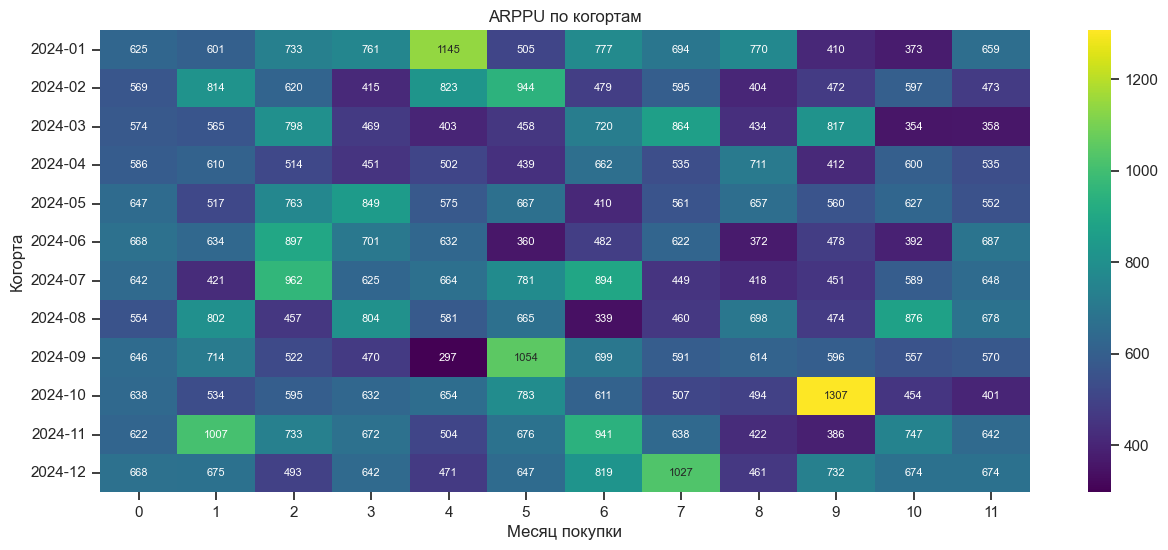

In [57]:
plt.figure(figsize=(15,6))

ax = sns.heatmap(
    df_cohort_arppu_heatmap,
    annot=True,
    fmt='.0f',
    cmap='viridis',
    annot_kws={'size':8}
)

plt.title('ARPPU по когортам')
plt.xlabel('Месяц покупки')
plt.ylabel('Когорта')

ax.set_xticks([i + 0.5 for i in range(len(df_cohort_arppu_heatmap.columns))])
ax.set_xticklabels(df_cohort_arppu_heatmap.columns.astype(int))

plt.show()

* не наблюдается периодов, в котором бы значительно изменился ARPPU по всем рассмотренным когортам одновременно, также не наблюдается значительных различий ARPPU между когортами - относительная стабильность показателя может быть связана с синтетической природой датасета

#### Lifetime Value

* Для расчета LTV выбраны когорты, существующие не менее 12 месяцев

In [58]:
# размеры когорт
df_cohort_size = df_cohort_users_p.iloc[::, :12].dropna().iloc[::, :1]

In [59]:
# ltv = gmv когорты за год / размер когорты
ltv = (df_cohort_gmv_heatmap.T.sum()/df_cohort_size.T.sum()).round().reset_index()

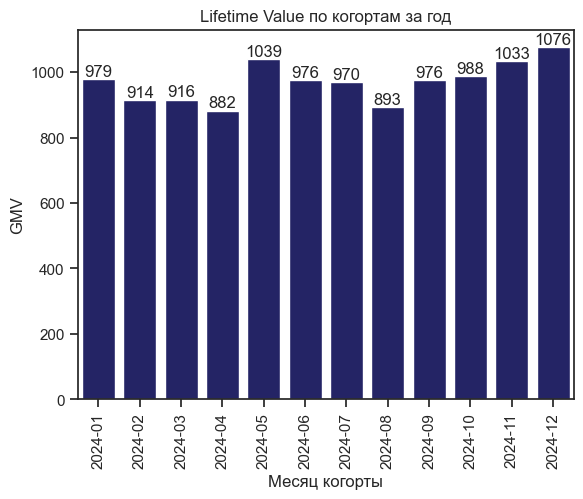

In [60]:
ax = sns.barplot(
    data=ltv,
    x='cohort_month',
    y=0,
    color='midnightblue',
    legend=False
)

for i in ax.containers:
    plt.bar_label(i)

plt.title('Lifetime Value по когортам за год')
plt.xlabel('Месяц когорты')
plt.ylabel('GMV')

plt.xticks(rotation=90)

plt.show()

Lifetime Value исследуемых когорт сопоставима.

### Событийная аналитика (Users & Events)

При попытке связать purchase-события с заказами через user_id было обнаружено, что одному событию purchase может соответствовать несколько различных order_id. Поскольку таблица events не содержит order_id, установить однозначное соответствие между событием покупки и конкретным заказом невозможно. В связи с этим в данном разделе были исключены денежные метрики и представлен только анализ пользовательской активности.

In [203]:
# SQL-запрос
query = '''select 
	date_trunc('month', e.event_timestamp ) as month,
	count(distinct e.user_id) as active_users,
	count(distinct e.user_id ) filter(where e.event_type = 'view') as users_with_view,
	count(distinct e.user_id ) filter(where e.event_type = 'wishlist') as users_with_wishlist,
	count(distinct e.user_id ) filter(where e.event_type = 'cart') as users_with_cart,
	count(distinct e.user_id ) filter(where e.event_type = 'purchase') as users_with_purchase
from events e 
where date_trunc('month', e.event_timestamp ) != date '2025-11-01'
group by date_trunc('month', e.event_timestamp );'''

df_month_events = pd.read_sql_query(query, engine)
df_month_events['month_label'] = df_month_events.month.dt.strftime('%Y-%m')

df_month_events.head()

,month,active_users,users_with_view,users_with_wishlist,users_with_cart,users_with_purchase,month_label
0,2024-01-01,3030,2206,371,545,201,2024-01
1,2024-02-01,2902,2098,333,523,170,2024-02
2,2024-03-01,3046,2236,349,547,177,2024-03
3,2024-04-01,2968,2179,362,508,191,2024-04
4,2024-05-01,3057,2290,353,515,174,2024-05


In [204]:
# SQL-запрос
query='''select 
	count(distinct e.user_id) as active_users,
	count(distinct e.user_id ) filter(where e.event_type = 'view') as users_with_view,
	count(distinct e.user_id ) filter(where e.event_type = 'wishlist') as users_with_wishlist,
	count(distinct e.user_id ) filter(where e.event_type = 'cart') as users_with_cart,
	count(distinct e.user_id ) filter(where e.event_type = 'purchase') as users_with_purchase
from events e'''

df_events = pd.read_sql_query(query, engine)
'''df_events = df_events.rename(columns={
	'active_users':'Active Users',
    'users_with_view':'View', 
    'users_with_wishlist':'Wishlist',
    'users_with_cart':'Cart',
    'users_with_purchase':'Purchase'})'''
df_events

,active_users,users_with_view,users_with_wishlist,users_with_cart,users_with_purchase
0,9995,9961,5504,6994,3281


#### Распределение событий

In [205]:
# вычисление долей
df_events_share = (df_events
                    .T
                    .div(df_events.active_users)
                    .mul(100)
                    .round(2)
                    .iloc[1:]
                    .rename(index={'users_with_view':'View',
                                    'users_with_wishlist':'Wishlist',
                                    'users_with_cart':'Cart',
                                    'users_with_purchase':'Purchase'})
                    .reset_index())

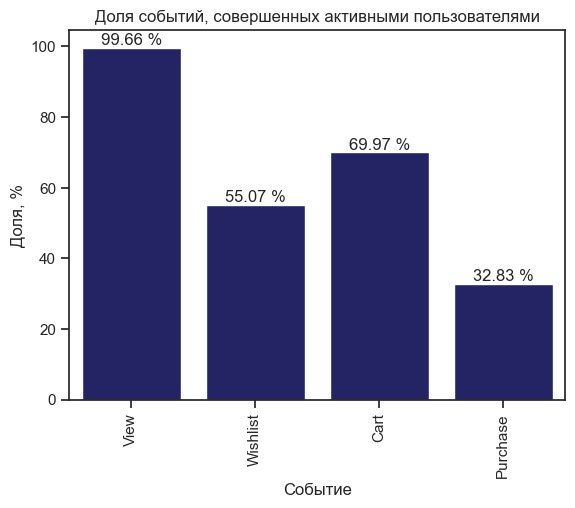

In [206]:
ax = sns.barplot(
    data=df_events_share,
    x='index',
    y=0,
    color='midnightblue',
    legend=False
)

ax.bar_label(
    ax.containers[0],
    labels=[f'{x} %' for x in df_events_share[0]]
)


plt.title('Доля событий, совершенных активными пользователями')
plt.xlabel('Событие')
plt.ylabel('Доля, %')

plt.xticks(rotation=90)

plt.show()

#### MAU & MAC

* в качестве customers принимаются пользователи, совершившие покупку

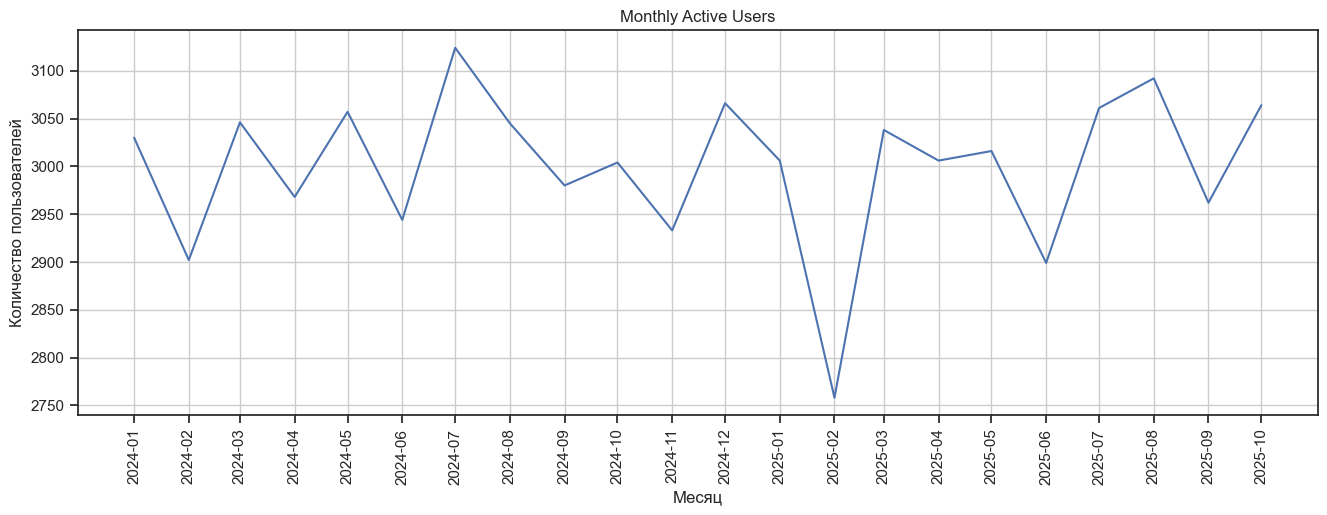

In [207]:
plt.figure(figsize=(16,5))

ax = sns.lineplot(
    data=df_month_events,
    x='month',
    y='active_users'
)

plt.title('Monthly Active Users')
plt.xlabel('Месяц')
plt.ylabel('Количество пользователей')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(df_month_events.month, rotation=90)
plt.grid()

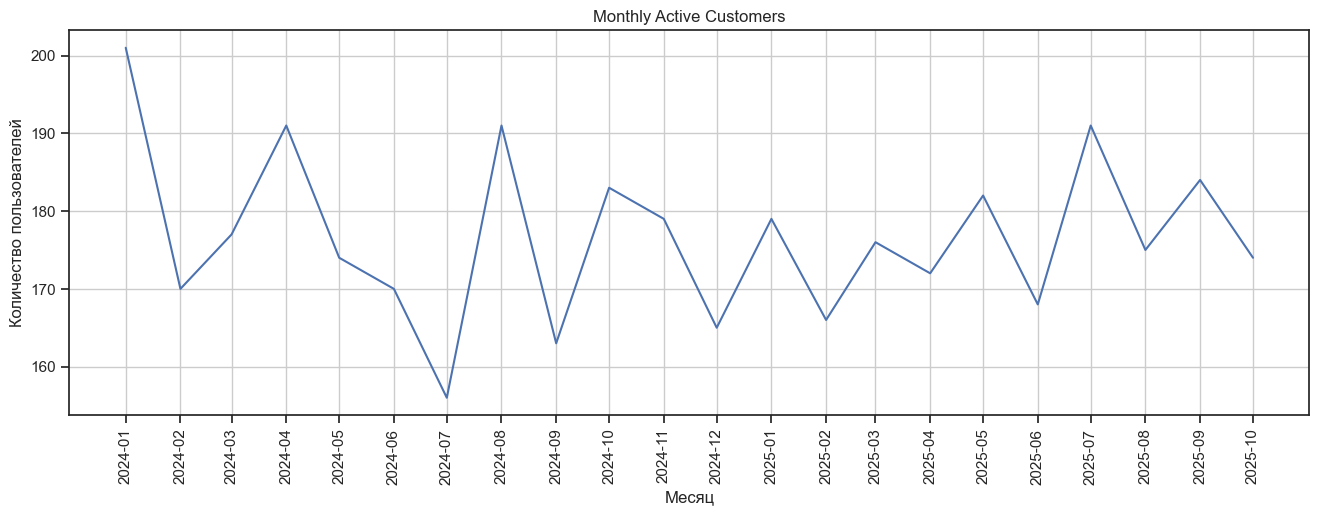

In [208]:
plt.figure(figsize=(16,5))

ax = sns.lineplot(
    data=df_month_events,
    x='month',
    y='users_with_purchase'
)

plt.title('Monthly Active Customers')
plt.xlabel('Месяц')
plt.ylabel('Количество пользователей')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(df_month_events.month, rotation=90)
plt.grid()

Не наблюдается сезонных или иных резких изменений MAU и MAC, данные показатели остаются стабильными на протяжении всего периода наблюдения

#### Конверсия (Conversion Rate) из MAU в MAC

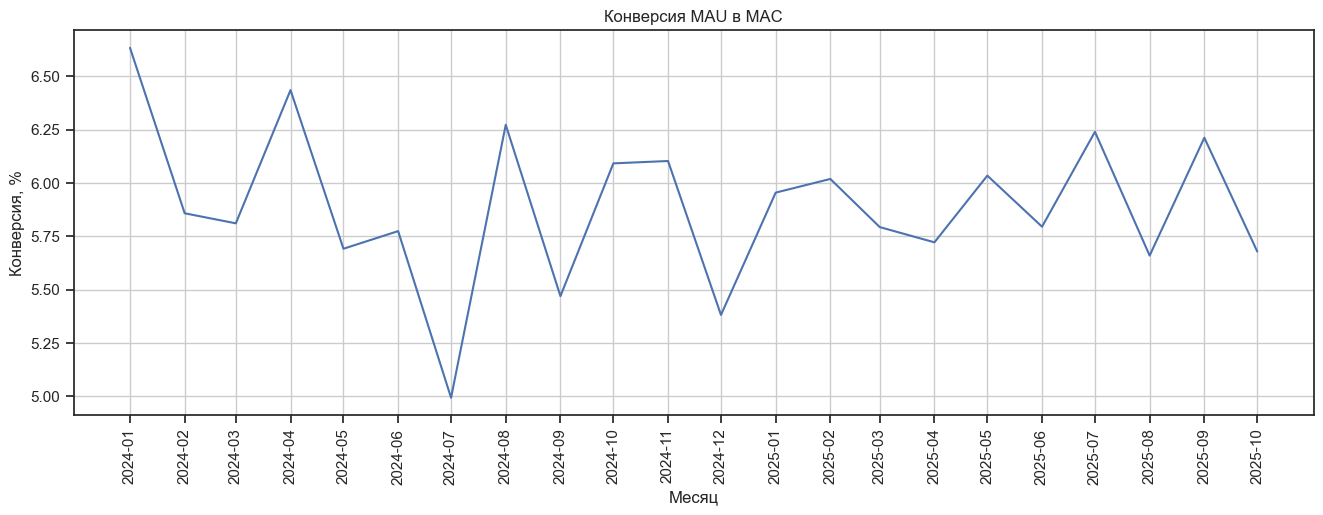

In [209]:
plt.figure(figsize=(16,5))

ax = sns.lineplot(
    data=df_month_events,
    x='month',
    y=(df_month_events.users_with_purchase/df_month_events.active_users)*100
)

plt.title('Конверсия MAU в MAC')
plt.xlabel('Месяц')
plt.ylabel('Конверсия, %')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(df_month_events.month, rotation=90)
plt.grid()

Конверсия активных пользователей в покупателей остается стабильной на протяжении всего периода наблюдения и не демонстрирует выраженных сезонных колебаний.

* наиболее частым действием является просмотр товара (View)
* наиболее редким действием является покупка товара (Purchase)
* событие Wishlist встречается реже, чем Cart

#### Конверсионная воронка view &rarr; cart &rarr; purchase

Т.к. событие Wishlist не является обязательным для совершения покупки, оно было исключено из воронки

In [212]:
# создание датафрейма с конверсиями

df_cr = pd.DataFrame({
    'month': df_month_events.month,
    'View → Cart': (df_month_events.users_with_cart / df_month_events.users_with_view)*100,
    'Cart → Purchase' : (df_month_events.users_with_purchase / df_month_events.users_with_cart)*100,
    'View → Purchase' : (df_month_events.users_with_purchase / df_month_events.users_with_view)*100
})

df_cr = df_cr.melt(
    id_vars='month',
    var_name='metric',
    value_name='cr' 
)

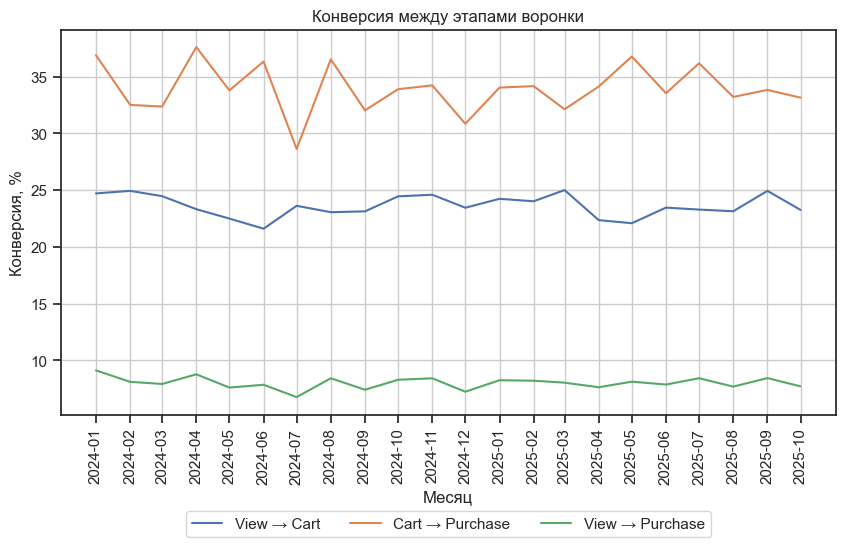

In [214]:
plt.figure(figsize=(10,5))

ax = sns.lineplot(
    data=df_cr,
    x='month',
    y='cr',
    hue='metric'
)

plt.title('Конверсия между этапами воронки')
plt.xlabel('Месяц')
plt.ylabel('Конверсия, %')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

ax.legend(
    bbox_to_anchor=(0.5, -0.23),
    loc='upper center',
    ncol=3
)

plt.xticks(df_month_events.month, rotation=90)
plt.grid()

Конверсии между этапами воронки остаются практически неизменными во времени. Наибольшие потери пользователей происходят на этапе перехода от просмотра товара к добавлению в корзину.

In [ ]:
# средние значения конверсий
df_cr[['metric', 'cr']].groupby('metric').mean().round(2)

,cr
metric,
Cart → Purchase,33.94
View → Cart,23.61
View → Purchase,8.01


## Резюме

|**Метрика**|**Значение**|**Комментарий**|
|:---|:---:|:---|
|Период анализа|январь 2024 - октябрь 2025|ноябрь 2025 исключен из-за неполных данных|
|Всего заказов|19 611|
|Количество успешных заказов|11 774|
|GMV успешных заказов|7 020 501|
|Среднее число заказов в месяц|891|
|AOV|595.9|
|Retention rate после 1-го месяца|4-7%|стабилен в дальнейшем|
|Конверсия View → Cart|23.6|стабильна|
|Конверсия Cart → Purchase|33.9|стабильна|
|Лидирующие категории по GMV|Electronics, Automotive|62,6 % совокупного GMV

Большинство метрик остаются стабильными на протяжении всего исследуемого периода, что, вероятно, связано с синтетической природой датасета